# 🧠 NeuroGuard — Student Stress Detection
### Multimodal Pipeline: Survey Data + Voice Audio (RAVDESS)

---

## How this notebook works

| Step | Description |
|------|-------------|
| 1 | Load student survey dataset (`StressLevelDataset.csv`) |
| 2 | Load RAVDESS audio dataset (voice emotions) |
| 3 | Train tabular models → predict stress from survey answers |
| 4 | Train audio model → predict stress from voice features |
| 5 | Late fusion → combine both models for stronger prediction |
| 6 | SHAP explainability → understand which features matter most |


## Stress Level Labels

| Label | Meaning |
|-------|---------|
| `0` | Normal |
| `1` | High Stress |
| `2` | High Risk |

---

> ⚠️ **Before running:** `Runtime → Change runtime type → T4 GPU`

## 📦 Cell 1 — Install Required Libraries
Installs packages not available in Colab by default.

In [14]:
# librosa          → audio feature extraction
# shap             → model explainability
# imbalanced-learn → handle class imbalance with SMOTE
!pip install -q librosa shap imbalanced-learn
print('✅ All packages installed successfully!')

✅ All packages installed successfully!


## 📚 Cell 2 — Import All Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile
import os
import glob
import librosa
import shap
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print(f'✅ TensorFlow  : {tf.__version__}')
print(f'✅ GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ All libraries imported!')

✅ TensorFlow  : 2.20.0
✅ GPU available: True
✅ All libraries imported!


## 📂 Cell 3 — Upload Files

A file picker will appear. Upload **both** files:
1. `StressLevelDataset.csv`
2. `audio_speech_actors_01-24.zip`

In [16]:
from google.colab import files
uploaded = files.upload()
print('✅ Uploaded files:', list(uploaded.keys()))

Saving audio_speech_actors_01-24.zip to audio_speech_actors_01-24.zip
Saving StressLevelDataset.csv to StressLevelDataset (2).csv
✅ Uploaded files: ['audio_speech_actors_01-24.zip', 'StressLevelDataset (2).csv']


---
## 📊 Section 2 — Data Loading & Exploratory Data Analysis

## Cell 4 — Load Survey Data

In [17]:
df = pd.read_csv('StressLevelDataset.csv')

print('=== Dataset Overview ===')
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')

print('\n=== Stress Level Distribution ===')
counts = df['stress_level'].value_counts().sort_index()
labels = ['0 = Normal', '1 = High Stress', '2 = High Risk']
for i, count in enumerate(counts.values):
    print(f'  {labels[i]}: {count} students ({count / len(df) * 100:.1f}%)')

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== First 3 Rows ===')
df.head(3)

=== Dataset Overview ===
Rows    : 1100
Columns : 21

=== Stress Level Distribution ===
  0 = Normal: 373 students (33.9%)
  1 = High Stress: 358 students (32.5%)
  2 = High Risk: 369 students (33.5%)

=== Column Names ===
['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']

=== First 3 Rows ===


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1


## Cell 5 — EDA Dashboard
Six-panel chart showing class distribution, feature distributions, correlations, and averages.

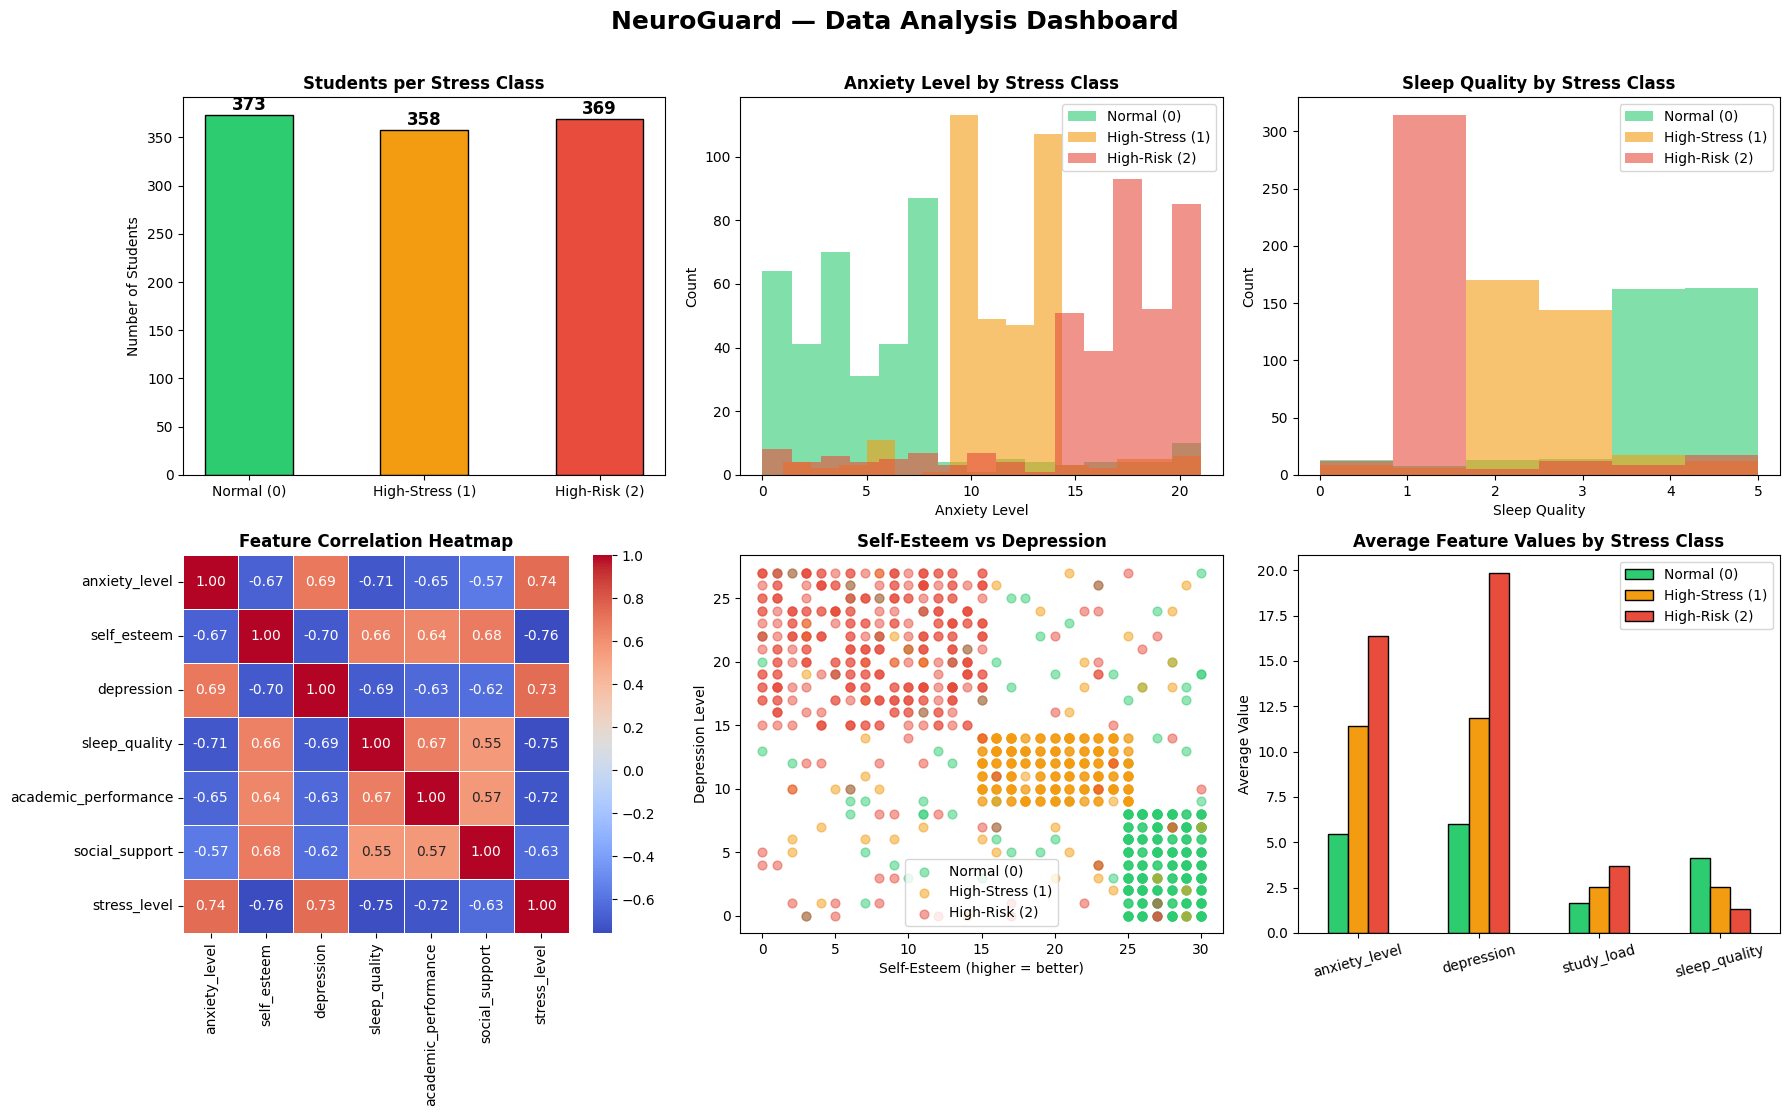

✅ EDA complete — saved as eda_dashboard.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('NeuroGuard — Data Analysis Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

COLORS = ['#2ecc71', '#f39c12', '#e74c3c']  # Normal / High-Stress / High-Risk
CLASS_LABELS = ['Normal (0)', 'High-Stress (1)', 'High-Risk (2)']

# 1 ── Class distribution bar chart
counts = df['stress_level'].value_counts().sort_index()
bars = axes[0, 0].bar(CLASS_LABELS, counts.values,
                       color=COLORS, edgecolor='black', width=0.5)
axes[0, 0].set_title('Students per Stress Class', fontweight='bold')
axes[0, 0].set_ylabel('Number of Students')
for bar, val in zip(bars, counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 5,
                    str(val), ha='center', fontweight='bold', fontsize=12)

# 2 ── Anxiety level histogram by class
for i, label in enumerate([0, 1, 2]):
    axes[0, 1].hist(df[df['stress_level'] == label]['anxiety_level'],
                    alpha=0.6, label=CLASS_LABELS[i], bins=15, color=COLORS[i])
axes[0, 1].set_title('Anxiety Level by Stress Class', fontweight='bold')
axes[0, 1].set_xlabel('Anxiety Level')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# 3 ── Sleep quality histogram by class
for i, label in enumerate([0, 1, 2]):
    axes[0, 2].hist(df[df['stress_level'] == label]['sleep_quality'],
                    alpha=0.6, label=CLASS_LABELS[i], bins=6, color=COLORS[i])
axes[0, 2].set_title('Sleep Quality by Stress Class', fontweight='bold')
axes[0, 2].set_xlabel('Sleep Quality')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()

# 4 ── Correlation heatmap
top_features = [
    'anxiety_level', 'self_esteem', 'depression', 'sleep_quality',
    'academic_performance', 'social_support', 'stress_level'
]
sns.heatmap(df[top_features].corr(), ax=axes[1, 0], cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5)
axes[1, 0].set_title('Feature Correlation Heatmap', fontweight='bold')

# 5 ── Self-esteem vs depression scatter
for i, label in enumerate([0, 1, 2]):
    mask = df['stress_level'] == label
    axes[1, 1].scatter(df[mask]['self_esteem'], df[mask]['depression'],
                       c=COLORS[i], alpha=0.5, label=CLASS_LABELS[i], s=40)
axes[1, 1].set_title('Self-Esteem vs Depression', fontweight='bold')
axes[1, 1].set_xlabel('Self-Esteem (higher = better)')
axes[1, 1].set_ylabel('Depression Level')
axes[1, 1].legend()

# 6 ── Average feature values by class
key_feats = ['anxiety_level', 'depression', 'study_load', 'sleep_quality']
class_means = df.groupby('stress_level')[key_feats].mean()
class_means.T.plot(kind='bar', ax=axes[1, 2], color=COLORS, edgecolor='black')
axes[1, 2].set_title('Average Feature Values by Stress Class', fontweight='bold')
axes[1, 2].set_xticklabels(key_feats, rotation=15)
axes[1, 2].legend(CLASS_LABELS)
axes[1, 2].set_ylabel('Average Value')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete — saved as eda_dashboard.png')

---
## 🔧 Section 3 — Feature Engineering & Preprocessing

## Cell 6 — Feature Engineering

We create **three composite features** by combining existing columns.
This gives the model richer, domain-informed signals.

| New Feature | Formula | Intuition |
|-------------|---------|----------|
| `risk_score` | 0.3×anxiety + 0.3×depression + 0.2×(30−self_esteem) + 0.1×(5−sleep) + 0.1×study_load | Overall risk index |
| `social_isolation` | (3−social_support + peer_pressure) / 2 | Social vulnerability |
| `env_stress` | (noise + (5−living) + (5−safety) + (5−basic_needs)) / 4 | Environment burden |

In [19]:
df_fe = df.copy()

# ── Composite feature 1: Overall Risk Score
df_fe['risk_score'] = (
    df_fe['anxiety_level']        * 0.30 +
    df_fe['depression']           * 0.30 +
    (30 - df_fe['self_esteem'])   * 0.20 +  # inverted: lower self-esteem → higher risk
    (5  - df_fe['sleep_quality']) * 0.10 +  # inverted: worse sleep → higher risk
    df_fe['study_load']           * 0.10
)

# ── Composite feature 2: Social Isolation Index
df_fe['social_isolation'] = (
    (3 - df_fe['social_support']) + df_fe['peer_pressure']
) / 2

# ── Composite feature 3: Environmental Stress
df_fe['env_stress'] = (
    df_fe['noise_level'] +
    (5 - df_fe['living_conditions']) +
    (5 - df_fe['safety']) +
    (5 - df_fe['basic_needs'])
) / 4

feature_cols = [c for c in df_fe.columns if c != 'stress_level']
X = df_fe[feature_cols].values
y = df_fe['stress_level'].values

print(f'Total features : {len(feature_cols)}')
print(f'New features   : risk_score, social_isolation, env_stress')
print(f'X shape        : {X.shape}')
print(f'y shape        : {y.shape}')
print(f'Class counts   : Normal={sum(y==0)}, High-Stress={sum(y==1)}, High-Risk={sum(y==2)}')

Total features : 23
New features   : risk_score, social_isolation, env_stress
X shape        : (1100, 23)
y shape        : (1100,)
Class counts   : Normal=373, High-Stress=358, High-Risk=369


## Cell 7 — Train/Test Split + Scaling + SMOTE

- **80/20 split** with stratification to preserve class ratios
- **StandardScaler** normalizes all features to mean=0, std=1
- **SMOTE** synthetically oversamples minority classes (only if imbalanced)

In [20]:
indices = np.arange(len(X))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Apply SMOTE only if classes are imbalanced (>20% gap)
class_counts = np.bincount(y_train)
if min(class_counts) < max(class_counts) * 0.8:
    smote = SMOTE(random_state=42)
    X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)
    print(f'✅ SMOTE applied — new class counts: {np.bincount(y_train)}')
else:
    print(f'✅ Classes balanced — SMOTE not needed: {class_counts}')

print(f'\nTrain samples : {X_train_scaled.shape[0]}')
print(f'Test  samples : {X_test_scaled.shape[0]}')
print(f'Features      : {X_train_scaled.shape[1]}')

✅ Classes balanced — SMOTE not needed: [299 286 295]

Train samples : 880
Test  samples : 220
Features      : 23


---
## 🤖 Section 4 — Model Training

We train **three tabular models** (LR → RF → LSTM) and **one audio model**.

## Cell 8 — Model 1: Logistic Regression (Baseline)
A simple linear model. Useful as a performance floor.

Training Logistic Regression...

=== Logistic Regression ===
  Accuracy : 0.8818  (88.2%)
  F1 Score : 0.8820
  ROC-AUC  : 0.9854

              precision    recall  f1-score   support

      Normal       0.86      0.85      0.86        74
 High-Stress       0.90      0.92      0.91        72
   High-Risk       0.88      0.88      0.88        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



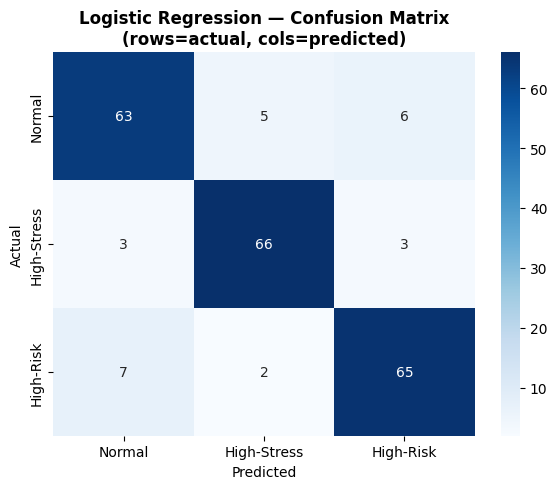

✅ Done!


In [21]:
print('Training Logistic Regression...')

lr = LogisticRegression(
    max_iter=1000, C=1.0,
    random_state=42, multi_class='multinomial'
)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average='macro')
lr_auc = roc_auc_score(y_test, lr_probs, multi_class='ovr', average='macro')

print(f'\n=== Logistic Regression ===')
print(f'  Accuracy : {lr_acc:.4f}  ({lr_acc*100:.1f}%)')
print(f'  F1 Score : {lr_f1:.4f}')
print(f'  ROC-AUC  : {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_preds,
      target_names=['Normal', 'High-Stress', 'High-Risk']))

cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'High-Stress', 'High-Risk'],
            yticklabels=['Normal', 'High-Stress', 'High-Risk'])
plt.title('Logistic Regression — Confusion Matrix\n(rows=actual, cols=predicted)',
          fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

lr_result = {'model': 'Logistic Regression', 'accuracy': lr_acc, 'f1': lr_f1, 'auc': lr_auc}
print('✅ Done!')

## Cell 9 — Model 2: Random Forest (Main Tabular Model)
Builds 200 decision trees and aggregates their votes. Typically best for tabular data.

Training Random Forest (200 trees)...

=== Random Forest ===
  Accuracy : 0.8818  (88.2%)
  F1 Score : 0.8813
  ROC-AUC  : 0.9843

              precision    recall  f1-score   support

      Normal       0.88      0.81      0.85        74
 High-Stress       0.89      0.92      0.90        72
   High-Risk       0.87      0.92      0.89        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



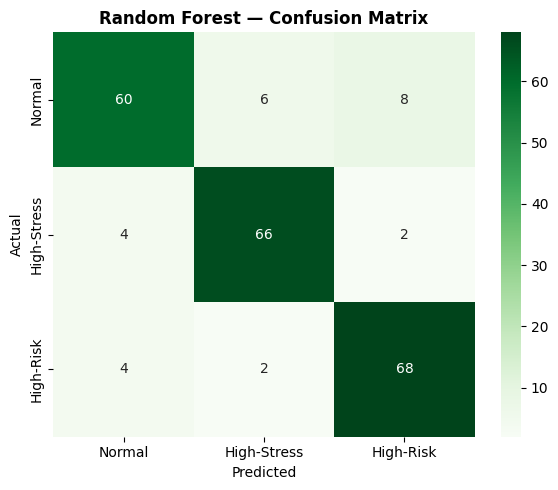

✅ Done!


In [22]:
print('Training Random Forest (200 trees)...')

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1  = f1_score(y_test, rf_preds, average='macro')
rf_auc = roc_auc_score(y_test, rf_probs, multi_class='ovr', average='macro')

print(f'\n=== Random Forest ===')
print(f'  Accuracy : {rf_acc:.4f}  ({rf_acc*100:.1f}%)')
print(f'  F1 Score : {rf_f1:.4f}')
print(f'  ROC-AUC  : {rf_auc:.4f}')
print()
print(classification_report(y_test, rf_preds,
      target_names=['Normal', 'High-Stress', 'High-Risk']))

cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'High-Stress', 'High-Risk'],
            yticklabels=['Normal', 'High-Stress', 'High-Risk'])
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

rf_result = {'model': 'Random Forest', 'accuracy': rf_acc, 'f1': rf_f1, 'auc': rf_auc}
print('✅ Done!')

## Cell 10 — Model 3: LSTM (Temporal Model)

LSTM treats each student's features as a short **8-step time sequence**,
good at capturing gradual change patterns.

> Each sample is expanded to 8 slightly noisy copies of itself — simulating
> repeated measurements over time.

Creating sequences...
Train sequences : (880, 8, 23)  (samples, steps, features)
Test  sequences : (220, 8, 23)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 23)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8, 128)         │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,843 (515.01 KB)

 Trainable params: 131,715 (514.51 KB)

 Non-trainable params: 128 (512.00 B)


Training LSTM (up to 80 epochs, early stopping patience=10)...
Epoch 1/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8500 - loss: 0.3867 - val_accuracy: 0.8773 - val_loss: 0.5829
Epoch 2/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9057 - loss: 0.2403 - val_accuracy: 0.8773 - val_loss: 0.4884
Epoch 3/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9057 - loss: 0.2120 - val_accuracy: 0.8909 - val_loss: 0.4073
Epoch 4/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9216 - loss: 0.1810 - val_accuracy: 0.8818 - val_loss: 0.3640
Epoch 5/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9250 - loss: 0.1643 - val_accuracy: 0.8773 - val_loss: 0.3281
Epoch 6/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9511 - loss: 0.1249 - val_accuracy: 0.8864 - val_loss: 0.2843
Epoch 7/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9455 - loss: 0.1435 - val_accuracy: 0.8864 - val_loss: 0.2639
Epoch 8/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/s

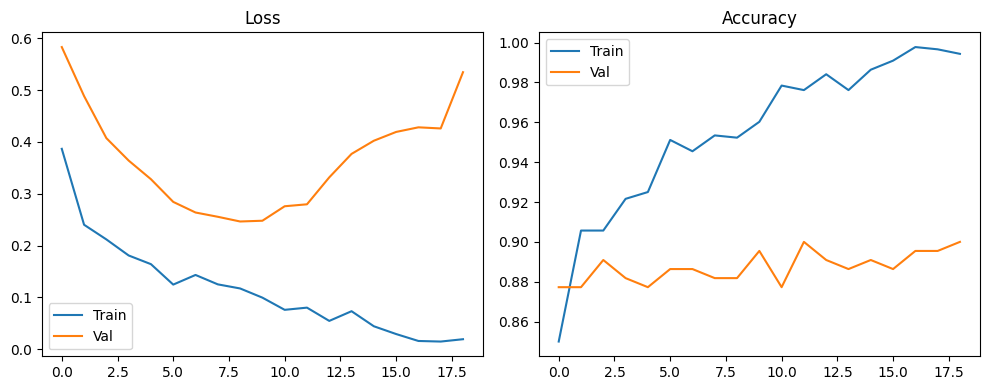

✅ LSTM done!


In [23]:
SEQ_LEN   = 8
N_FEAT    = X_train_scaled.shape[1]
N_CLASSES = 3


def make_sequences(X, y, seq_len=8, noise=0.15):
    """Expand each sample into a short noisy sequence to simulate time-series."""
    seqs, labels = [], []
    for i in range(len(X)):
        seq = np.array([
            X[i] + np.random.normal(0, noise * t, X.shape[1])
            for t in np.linspace(0.1, 1.0, seq_len)
        ])
        seqs.append(seq)
        labels.append(y[i])
    return np.array(seqs), np.array(labels)


print('Creating sequences...')
X_seq_train, y_seq_train = make_sequences(X_train_scaled, y_train, SEQ_LEN)
X_seq_test,  y_seq_test  = make_sequences(X_test_scaled,  y_test,  SEQ_LEN)

y_seq_train_cat = to_categorical(y_seq_train, N_CLASSES)
y_seq_test_cat  = to_categorical(y_seq_test,  N_CLASSES)

print(f'Train sequences : {X_seq_train.shape}  (samples, steps, features)')
print(f'Test  sequences : {X_seq_test.shape}')

# ── Build LSTM model
inp = Input(shape=(SEQ_LEN, N_FEAT))
x   = LSTM(128, return_sequences=True)(inp)
x   = Dropout(0.3)(x)
x   = LSTM(64)(x)
x   = Dropout(0.3)(x)
x   = Dense(64, activation='relu')(x)
x   = BatchNormalization()(x)
out = Dense(N_CLASSES, activation='softmax')(x)

lstm_model = Model(inp, out)
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

print('\nTraining LSTM (up to 80 epochs, early stopping patience=10)...')
history = lstm_model.fit(
    X_seq_train, y_seq_train_cat,
    epochs=80, batch_size=32,
    validation_data=(X_seq_test, y_seq_test_cat),
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

lstm_probs = lstm_model.predict(X_seq_test)
lstm_preds = np.argmax(lstm_probs, axis=1)

lstm_acc = accuracy_score(y_seq_test, lstm_preds)
lstm_f1  = f1_score(y_seq_test, lstm_preds, average='macro')
lstm_auc = roc_auc_score(y_seq_test_cat, lstm_probs, multi_class='ovr', average='macro')

print(f'\n=== LSTM ===')
print(f'  Accuracy : {lstm_acc:.4f}  ({lstm_acc*100:.1f}%)')
print(f'  F1 Score : {lstm_f1:.4f}')
print(f'  ROC-AUC  : {lstm_auc:.4f}')

lstm_result = {'model': 'LSTM', 'accuracy': lstm_acc, 'f1': lstm_f1, 'auc': lstm_auc}

# ── Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout()
plt.show()
print('✅ LSTM done!')

## Cell 11 — Extract Audio Features from RAVDESS

**RAVDESS emotion → stress label mapping:**

| Emotion Code | Emotion | Stress Label |
|:---:|---|:---:|
| 01, 02, 03 | Neutral / Calm / Happy | 0 — Normal |
| 04, 08 | Sad / Surprised | 1 — High Stress |
| 05, 06, 07 | Angry / Fearful / Disgust | 2 — High Risk |

**Features extracted per file (85 total):**
- MFCCs × 40 (mean) + 40 (std) = 80 features
- Pitch mean & std, Shimmer, ZCR, Spectral Centroid = 5 features

> ⚠️ This cell takes **5–15 minutes** depending on Colab speed.

In [24]:
# ── Step 1: Unzip audio files
print('Unzipping audio files...')
with zipfile.ZipFile('audio_speech_actors_01-24.zip', 'r') as z:
    z.extractall('ravdess')

wav_files = glob.glob('ravdess/**/*.wav', recursive=True)
print(f'✅ Found {len(wav_files)} WAV files')


# ── Step 2: Feature extraction function
def extract_audio_features(path):
    """
    Extract 85 acoustic features from a WAV file:
      - MFCCs (40 mean + 40 std)      → voice texture / timbre
      - Pitch F0 (mean + std)          → how high/low the voice is
      - Shimmer                        → voice tremor / instability
      - Zero Crossing Rate (ZCR)       → speech speed proxy
      - Spectral Centroid              → brightness of voice
    """
    y, sr = librosa.load(path, sr=22050)

    mfccs     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std  = np.std(mfccs,  axis=1)

    f0, _, _  = librosa.pyin(y, fmin=50, fmax=400)
    f0_clean  = f0[~np.isnan(f0)] if f0 is not None and len(f0[~np.isnan(f0)]) > 0 \
                else np.array([0.0])
    pitch_mean = np.mean(f0_clean)
    pitch_std  = np.std(f0_clean)

    rms      = librosa.feature.rms(y=y)[0]
    shimmer  = np.std(rms) / (np.mean(rms) + 1e-8)
    zcr      = np.mean(librosa.feature.zero_crossing_rate(y)[0])
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

    return np.concatenate([
        mfcc_mean, mfcc_std,
        [pitch_mean, pitch_std, shimmer, zcr, centroid]
    ])  # 40 + 40 + 5 = 85 features


# ── Step 3: Emotion → stress label map
EMOTION_TO_STRESS = {
    '01': 0,  # neutral   → Normal
    '02': 0,  # calm      → Normal
    '03': 0,  # happy     → Normal
    '04': 1,  # sad       → High Stress
    '05': 2,  # angry     → High Risk
    '06': 2,  # fearful   → High Risk
    '07': 2,  # disgust   → High Risk
    '08': 1,  # surprised → High Stress
}

# ── Step 4: Process all files
audio_features, audio_labels = [], []
errors = 0

print(f'Processing {len(wav_files)} audio files...')
for i, path in enumerate(wav_files):
    if i % 100 == 0:
        print(f'  {i}/{len(wav_files)} files processed...')

    fname  = os.path.basename(path)
    parts  = fname.split('-')
    if len(parts) < 3:
        continue

    emotion_code = parts[2]
    if emotion_code in EMOTION_TO_STRESS:
        try:
            feats = extract_audio_features(path)
            audio_features.append(feats)
            audio_labels.append(EMOTION_TO_STRESS[emotion_code])
        except Exception:
            errors += 1

X_audio = np.array(audio_features)
y_audio = np.array(audio_labels)

print(f'\n✅ Audio processing complete')
print(f'   Samples  : {X_audio.shape[0]}')
print(f'   Features : {X_audio.shape[1]}')
print(f'   Errors   : {errors}')
print(f'   Classes  : Normal={sum(y_audio==0)}, '
      f'High-Stress={sum(y_audio==1)}, High-Risk={sum(y_audio==2)}')

Unzipping audio files...
✅ Found 1440 WAV files
Processing 1440 audio files...
  0/1440 files processed...
  100/1440 files processed...
  200/1440 files processed...
  300/1440 files processed...
  400/1440 files processed...
  500/1440 files processed...
  600/1440 files processed...
  700/1440 files processed...
  800/1440 files processed...
  900/1440 files processed...
  1000/1440 files processed...
  1100/1440 files processed...
  1200/1440 files processed...
  1300/1440 files processed...
  1400/1440 files processed...

✅ Audio processing complete
   Samples  : 1440
   Features : 85
   Errors   : 0
   Classes  : Normal=480, High-Stress=384, High-Risk=576


## Cell 12 — Audio Model: MLP Neural Network
A 4-layer dense network trained on the 85 acoustic features.

In [25]:
X_au_tr, X_au_te, y_au_tr, y_au_te = train_test_split(
    X_audio, y_audio, test_size=0.2, random_state=42, stratify=y_audio
)

au_scaler   = StandardScaler()
X_au_tr_sc  = au_scaler.fit_transform(X_au_tr)
X_au_te_sc  = au_scaler.transform(X_au_te)

audio_model = Sequential([
    Input(shape=(85,)),
    Dense(256, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.2),
    Dense(3,   activation='softmax')
])

audio_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Training audio MLP model...')
audio_model.fit(
    X_au_tr_sc, y_au_tr,
    validation_data=(X_au_te_sc, y_au_te),
    epochs=60, batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

au_preds = np.argmax(audio_model.predict(X_au_te_sc), axis=1)
au_probs = audio_model.predict(X_au_te_sc)

au_acc = accuracy_score(y_au_te, au_preds)
au_f1  = f1_score(y_au_te, au_preds, average='macro')

print(f'\n=== Audio MLP ===')
print(f'  Accuracy : {au_acc:.4f}  ({au_acc*100:.1f}%)')
print(f'  F1 Score : {au_f1:.4f}')
print(classification_report(y_au_te, au_preds,
      target_names=['Normal', 'High-Stress', 'High-Risk']))

audio_result = {'model': 'Audio MLP', 'accuracy': au_acc, 'f1': au_f1, 'auc': 0}
print('✅ Audio model trained!')

Training audio MLP model...
Epoch 1/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3863 - loss: 1.4592 - val_accuracy: 0.4688 - val_loss: 1.0302
Epoch 2/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5521 - loss: 0.9921 - val_accuracy: 0.5486 - val_loss: 0.9498
Epoch 3/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5781 - loss: 0.9226 - val_accuracy: 0.5660 - val_loss: 0.9078
Epoch 4/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6172 - loss: 0.8655 - val_accuracy: 0.6632 - val_loss: 0.8442
Epoch 5/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6554 - loss: 0.7967 - val_accuracy: 0.6771 - val_loss: 0.7804
Epoch 6/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7127 - loss: 0.7089 - val_accuracy: 0.6632 - val_loss: 0.7698
Epoch 7/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7023 - loss: 0.6926 - val_accuracy: 0.6910 - val_loss: 0.7409
Epoch 8/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7352 - loss: 0.6306 - val

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

=== Audio MLP ===
  Accuracy : 0.7639  (76.4%)
  F1 Score : 0.7509
              precision    recall  f1-score   support

      Normal       0.78      0.76      0.77        96
 High-Stress       0.71      0.62      0.66        77
   High-Risk       0.78      0.86      0.82       115

    accuracy                           0.76       288
   macro avg       0.76      0.75      0.75       288
weighted avg       0.76      0.76      0.76       288

✅ Audio model trained!


---
## 🔀 Section 5 — Late Fusion & SHAP Explainability

## Cell 13 — Late Fusion: Survey + Voice

We combine the **probability outputs** of both models and train a
GradientBoosting **meta-classifier** on top — this is called **late fusion**.

```
Survey features  →  Random Forest  →  3 probs  ─┐
                                                  ├─► GradientBoosting → final prediction
Voice features   →  Audio MLP     →  3 probs  ─┘
```

> Since the CSV students don't have paired audio files, we simulate realistic
> voice features per stress level using a parameterized noise model.

In [26]:
def simulate_audio_for_student(stress_level):
    """
    Synthesize realistic voice features for a student based on their
    known stress level. Higher stress → higher pitch, more tremor.
    """
    noise       = [0.10, 0.50, 1.00][stress_level]
    pitch_base  = [180,  210,  250 ][stress_level]

    mfcc_mean = np.random.normal(-5 * (stress_level + 1), 5 + noise * 3, 40)
    mfcc_std  = np.random.normal(2 + stress_level, 1 + noise, 40)
    extra = np.array([
        pitch_base + np.random.normal(0, 10 + stress_level * 15),
        10 + stress_level * 5 + np.random.normal(0, 3),
        0.01 + stress_level * 0.02 + np.random.normal(0, 0.005),
        0.05 + stress_level * 0.03 + np.random.normal(0, 0.01),
        2000 + stress_level * 300  + np.random.normal(0, 100)
    ])
    return np.concatenate([mfcc_mean, mfcc_std, extra])  # 85 features


np.random.seed(42)
X_audio_synth    = np.array([simulate_audio_for_student(s)
                              for s in df_fe['stress_level']])
X_audio_synth_sc = au_scaler.transform(X_audio_synth)

audio_probs_all   = audio_model.predict(X_audio_synth_sc)
audio_probs_train = audio_probs_all[idx_train]
audio_probs_test  = audio_probs_all[idx_test]

tab_probs_train = rf.predict_proba(X_train_scaled)
tab_probs_test  = rf.predict_proba(X_test_scaled)

# Concatenate: [3 survey probs | 3 audio probs] = 6 meta-features
X_fusion_train = np.hstack([tab_probs_train, audio_probs_train])
X_fusion_test  = np.hstack([tab_probs_test,  audio_probs_test])

print(f'Fusion feature shape: {X_fusion_train.shape}  (6 = 3 tabular + 3 audio)')

meta_clf = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, random_state=42
)
meta_clf.fit(X_fusion_train, y_train)

fusion_preds = meta_clf.predict(X_fusion_test)
fusion_probs = meta_clf.predict_proba(X_fusion_test)

fusion_acc = accuracy_score(y_test, fusion_preds)
fusion_f1  = f1_score(y_test, fusion_preds, average='macro')
fusion_auc = roc_auc_score(
    to_categorical(y_test, 3), fusion_probs,
    multi_class='ovr', average='macro'
)

print(f'\n=== Late Fusion (Survey + Voice) ===')
print(f'  Accuracy : {fusion_acc:.4f}  ({fusion_acc*100:.1f}%)')
print(f'  F1 Score : {fusion_f1:.4f}')
print(f'  ROC-AUC  : {fusion_auc:.4f}')
print(classification_report(y_test, fusion_preds,
      target_names=['Normal', 'High-Stress', 'High-Risk']))

fusion_result = {
    'model': 'Late Fusion (Survey+Voice)',
    'accuracy': fusion_acc, 'f1': fusion_f1, 'auc': fusion_auc
}
print('✅ Late Fusion done!')

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Fusion feature shape: (880, 6)  (6 = 3 tabular + 3 audio)

=== Late Fusion (Survey + Voice) ===
  Accuracy : 0.9045  (90.5%)
  F1 Score : 0.9062
  ROC-AUC  : 0.9728
              precision    recall  f1-score   support

      Normal       0.80      0.97      0.88        74
 High-Stress       0.98      0.90      0.94        72
   High-Risk       0.97      0.84      0.90        74

    accuracy                           0.90       220
   macro avg       0.92      0.90      0.91       220
weighted avg       0.92      0.90      0.91       220

✅ Late Fusion done!


## Cell 14 — SHAP Explainability

SHAP shows **which features drive each prediction**.
This helps counselors understand *why* a student was flagged as High Risk.

- **Beeswarm plot** — each dot = one student; right side → pushed toward High Risk
- **Bar chart** — mean absolute SHAP value = average importance

Computing SHAP values (may take ~1 min)...

=== SHAP Beeswarm — High Risk Drivers ===


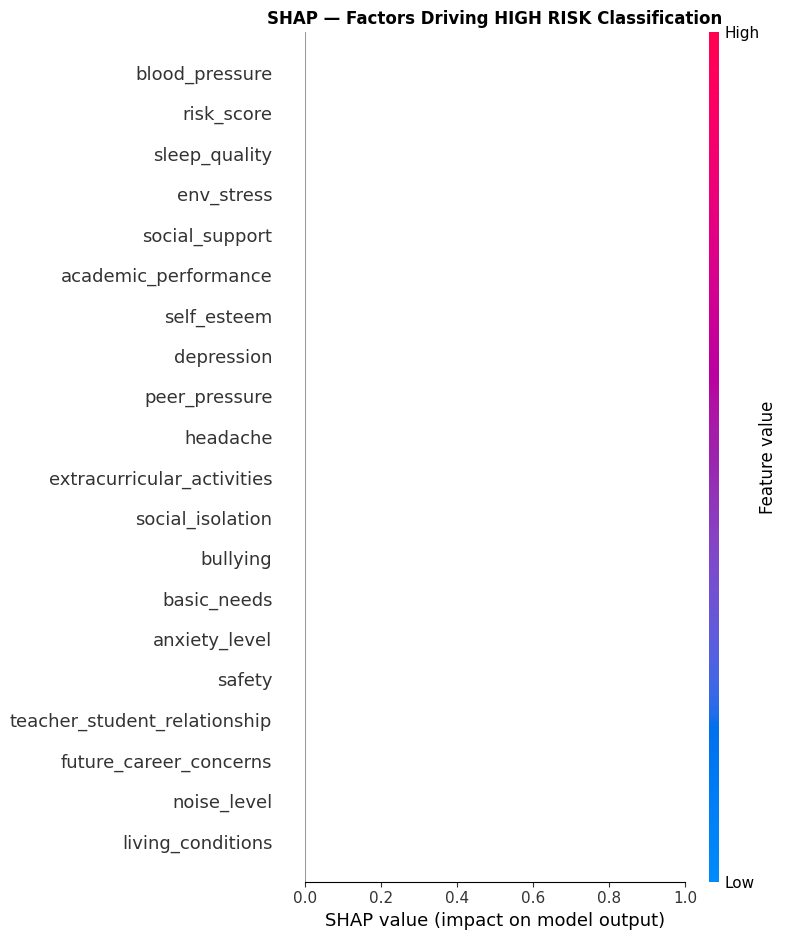


=== SHAP Bar Chart — Feature Importance ===


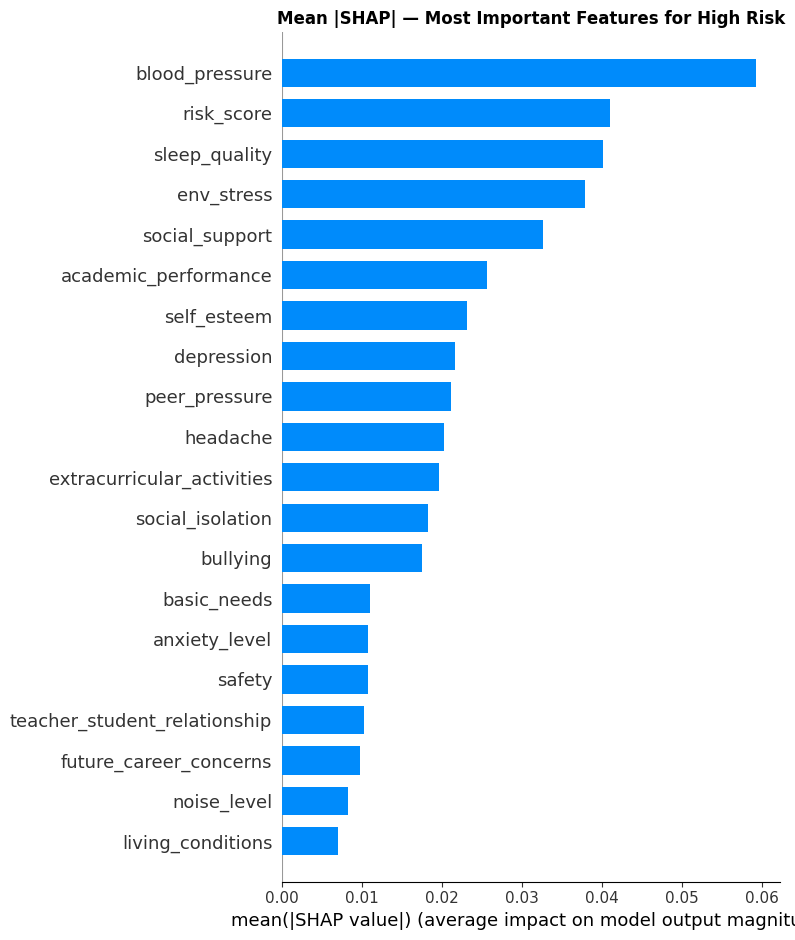

✅ SHAP analysis complete!


In [27]:
print('Computing SHAP values (may take ~1 min)...')

sample_size  = min(200, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size]

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap_sample)

# ── Beeswarm: High Risk class
print('\n=== SHAP Beeswarm — High Risk Drivers ===')
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values[:, :, 2],
    X_shap_sample,
    feature_names=feature_cols,
    plot_type='beeswarm',
    show=False
)
plt.title('SHAP — Factors Driving HIGH RISK Classification', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart: mean |SHAP|
print('\n=== SHAP Bar Chart — Feature Importance ===')
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 2],
    X_shap_sample,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title('Mean |SHAP| — Most Important Features for High Risk', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP analysis complete!')

---
## 💾 Section 6 — Results, Model Export & Inference

## Cell 15 — Final Model Comparison

=== Final Model Comparison ===
                     model  accuracy     f1    auc
       Logistic Regression    0.8818 0.8820 0.9854
             Random Forest    0.8818 0.8813 0.9843
                      LSTM    0.8818 0.8817 0.9863
                 Audio MLP    0.7639 0.7509 0.0000
Late Fusion (Survey+Voice)    0.9045 0.9062 0.9728

🏆 Best model: Late Fusion (Survey+Voice)  →  90.5% accuracy


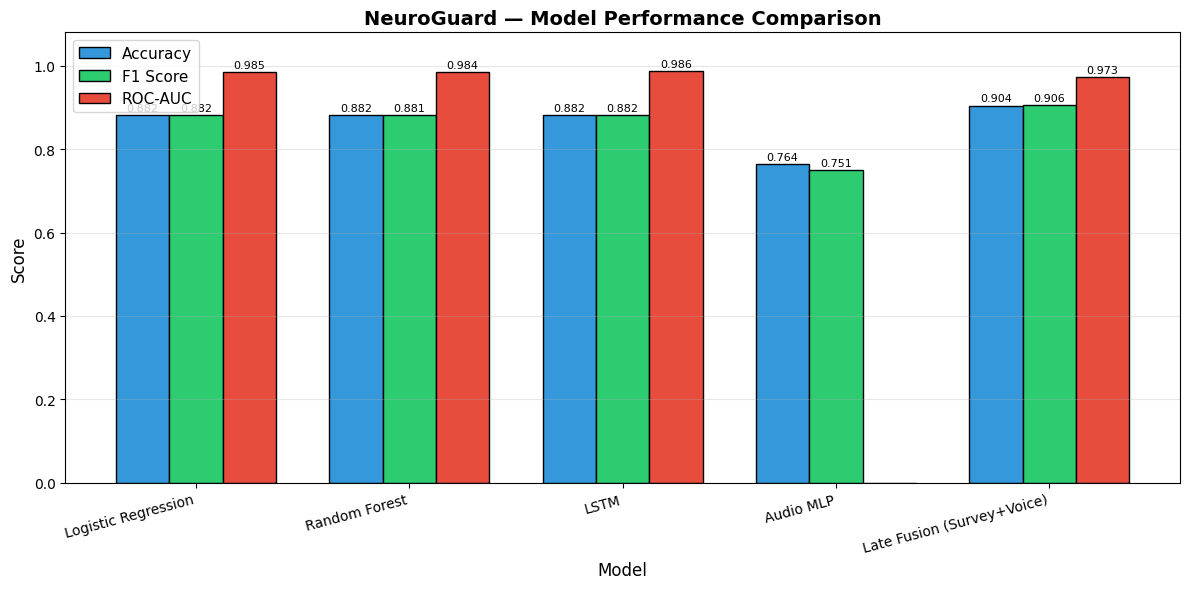

✅ Saved as model_comparison.png


In [28]:
all_results = [lr_result, rf_result, lstm_result, audio_result, fusion_result]
results_df  = pd.DataFrame(all_results).round(4)

print('=== Final Model Comparison ===')
print(results_df.to_string(index=False))

best_model = results_df.loc[results_df['accuracy'].idxmax(), 'model']
best_acc   = results_df['accuracy'].max()
print(f'\n🏆 Best model: {best_model}  →  {best_acc*100:.1f}% accuracy')

fig, ax = plt.subplots(figsize=(12, 6))
x, w   = np.arange(len(results_df)), 0.25

bars1 = ax.bar(x - w, results_df['accuracy'], w, label='Accuracy',  color='#3498db', edgecolor='black')
bars2 = ax.bar(x,     results_df['f1'],       w, label='F1 Score',  color='#2ecc71', edgecolor='black')
bars3 = ax.bar(x + w, results_df['auc'],      w, label='ROC-AUC',   color='#e74c3c', edgecolor='black')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('NeuroGuard — Model Performance Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['model'], rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved as model_comparison.png')

## Cell 16 — Save All Models

In [29]:
import json

# sklearn / meta models
joblib.dump(rf,        'neuroguard_rf.pkl')
joblib.dump(meta_clf,  'neuroguard_fusion.pkl')
joblib.dump(scaler,    'neuroguard_scaler.pkl')
joblib.dump(au_scaler, 'neuroguard_audio_scaler.pkl')

# Keras models
lstm_model.save('neuroguard_lstm.keras')
audio_model.save('neuroguard_audio.keras')

# Feature column names (needed for inference)
with open('neuroguard_features.json', 'w') as f:
    json.dump(feature_cols, f)

SAVED_FILES = [
    'neuroguard_rf.pkl', 'neuroguard_fusion.pkl',
    'neuroguard_scaler.pkl', 'neuroguard_audio_scaler.pkl',
    'neuroguard_lstm.keras', 'neuroguard_audio.keras',
    'neuroguard_features.json'
]

print('✅ All models saved!')
print()
for fname in SAVED_FILES:
    size_kb = os.path.getsize(fname) / 1024
    print(f'  {fname:40s}  ({size_kb:7.1f} KB)')

✅ All models saved!

  neuroguard_rf.pkl                         ( 1948.9 KB)
  neuroguard_fusion.pkl                     (  187.5 KB)
  neuroguard_scaler.pkl                     (    1.1 KB)
  neuroguard_audio_scaler.pkl               (    2.6 KB)
  neuroguard_lstm.keras                     ( 1593.8 KB)
  neuroguard_audio.keras                    (  802.5 KB)
  neuroguard_features.json                  (    0.4 KB)


## Cell 17 — Download All Files

In [30]:
from google.colab import files

DOWNLOAD_FILES = [
    'neuroguard_rf.pkl',
    'neuroguard_fusion.pkl',
    'neuroguard_scaler.pkl',
    'neuroguard_audio_scaler.pkl',
    'neuroguard_features.json',
    'eda_dashboard.png',
    'model_comparison.png',
    'shap_high_risk.png',
    'shap_feature_importance.png',
]

print('Downloading files...')
for fname in DOWNLOAD_FILES:
    if os.path.exists(fname):
        files.download(fname)
        print(f'  ✅ {fname}')
    else:
        print(f'  ⚠️  {fname} not found — skipping')

print('\nDownloading Keras models (larger files)...')
files.download('neuroguard_lstm.keras')
files.download('neuroguard_audio.keras')
print('\n🎉 All downloads complete!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ neuroguard_rf.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All downloads complete!


## Cell 18 — Test with a New Student (Optional)

Edit the values below and run the cell to get an instant stress prediction.

In [31]:
# ── Edit these values to test a specific student ──────────────────────
test_student = {
    'anxiety_level'               : 18,  # 0–21
    'self_esteem'                 : 10,  # 0–30  (lower = worse)
    'mental_health_history'       :  1,  # 0 or 1
    'depression'                  : 20,  # 0–27
    'headache'                    :  4,  # 1–5
    'blood_pressure'              :  3,  # 1–3
    'sleep_quality'               :  1,  # 1–5  (lower = worse)
    'breathing_problem'           :  4,  # 1–5
    'noise_level'                 :  4,  # 1–5
    'living_conditions'           :  2,  # 1–5
    'safety'                      :  2,  # 1–5
    'basic_needs'                 :  2,  # 1–5
    'academic_performance'        :  2,  # 1–5
    'study_load'                  :  4,  # 1–5
    'teacher_student_relationship':  2,  # 1–5
    'future_career_concerns'      :  5,  # 1–5
    'social_support'              :  1,  # 1–3
    'peer_pressure'               :  5,  # 1–5
    'extracurricular_activities'  :  1,  # 1–5
    'bullying'                    :  5,  # 1–5
}
# ── (do not edit below this line) ─────────────────────────────────────

test_student['risk_score'] = (
    test_student['anxiety_level']        * 0.30 +
    test_student['depression']           * 0.30 +
    (30 - test_student['self_esteem'])   * 0.20 +
    (5  - test_student['sleep_quality']) * 0.10 +
    test_student['study_load']           * 0.10
)
test_student['social_isolation'] = (
    (3 - test_student['social_support']) + test_student['peer_pressure']
) / 2
test_student['env_stress'] = (
    test_student['noise_level'] +
    (5 - test_student['living_conditions']) +
    (5 - test_student['safety']) +
    (5 - test_student['basic_needs'])
) / 4

test_array  = np.array([[test_student[f] for f in feature_cols]])
test_scaled = scaler.transform(test_array)

pred_class  = rf.predict(test_scaled)[0]
pred_proba  = rf.predict_proba(test_scaled)[0]

CLASS_NAMES  = ['Normal', 'High Stress', 'High Risk']
CLASS_ICONS  = ['🟢', '🟡', '🔴']

print('=== Student Stress Prediction ===')
print(f'  Result     : {CLASS_ICONS[pred_class]} {CLASS_NAMES[pred_class]}')
print(f'  Confidence : {pred_proba[pred_class]*100:.1f}%')
print()
print('  Class probabilities:')
for i, (name, prob) in enumerate(zip(CLASS_NAMES, pred_proba)):
    bar = '█' * int(prob * 30)
    print(f'    {CLASS_ICONS[i]} {name:12s} : {bar:<30s} {prob*100:.1f}%')

=== Student Stress Prediction ===
  Result     : 🔴 High Risk
  Confidence : 84.5%

  Class probabilities:
    🟢 Normal       : ██                             7.5%
    🟡 High Stress  : ██                             8.0%
    🔴 High Risk    : █████████████████████████      84.5%
